# Composites of other variables based on TAM phases 1-8

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import usefulfunc as uf
import xarray as xr
import os
import gc
from scipy.signal import correlate
from matplotlib.colors import TwoSlopeNorm
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from IPython.display import display, HTML

In [2]:
WORK = os.environ["WORK"]   

## Composites of Different Variables based on TAM phase

In [3]:
zmzanom = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmzdanoms1979_2023.nc')
zmzstack = zmzanom.Z.stack(alltime = ('year', 'time'))
zmzanomtss, lowpzmza = uf.butter1yhighp(zmzstack, 4)

In [4]:
zmupvpdanoms79_23 = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmupvpdanoms1979_2023.nc')
zmTdanoms79_23 = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmTdanoms1979_2023.nc')
zmUdanoms79_23 = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmUdanoms1979_2023.nc')
zmwstardanoms79_23 = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmwstardanoms1979_2023.nc')
zmWdanoms79_23 = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmWdanoms1979_2023.nc')

In [5]:
zmwstardanomts = zmwstardanoms79_23['w*'].stack(alltime = ('year', 'time'))
zmupvpdanomts = zmupvpdanoms79_23.upvp.stack(alltime = ('year', 'time'))
zmUdanomts = zmUdanoms79_23.U.stack(alltime = ('year', 'time'))
zmTdanomts = zmTdanoms79_23.T.stack(alltime = ('year', 'time'))
zmWdanomts = zmWdanoms79_23.W.stack(alltime = ('year', 'time'))

In [6]:
highpzmupvpa, lowpzmupvpa = uf.butter1yhighp(zmupvpdanomts, 4)
highpzmUa, lowpzmUa = uf.butter1yhighp(zmUdanomts, 4)
highpzmTa, lowpzmTa = uf.butter1yhighp(zmTdanomts, 4)
highpwstara, lowpwstara = uf.butter1yhighp(zmwstardanomts, 4)
highpWa, lowpWa = uf.butter1yhighp(zmWdanomts, 4)

In [7]:
edge_trim = 183
zmzanomts = zmzanomtss.isel(alltime=slice(edge_trim, -edge_trim))
highpUshaved = highpzmUa.isel(alltime=slice(edge_trim, -edge_trim))
highpTshaved = highpzmTa.isel(alltime=slice(edge_trim, -edge_trim))
highpupvpshaved = highpzmupvpa.isel(alltime=slice(edge_trim, -edge_trim))
highpwstarshaved = highpwstara.isel(alltime=slice(edge_trim, -edge_trim))
highpWshaved = highpWa.isel(alltime=slice(edge_trim, -edge_trim))

In [8]:
# 1. Preprocessing (same as before)
R_earth = 6.371e6
upvp_merid_div = -highpupvpshaved.differentiate('latitude') * (180/np.pi) / R_earth

# 2. Unit conversion
upvp_merid_div_perday = upvp_merid_div * 86400

# 3. Latavg -15 to 15, consistent with GPH/T/u/w* composites
upvp_merid_div_trop = uf.latavg(upvp_merid_div_perday, -15, 15)

# 4. Composite
#comp_upvpdiv_physical, comp_upvpdiv_norm = phase_composite(
   # upvp_merid_div_trop, phase, A, threshold=1.0
#)

In [9]:
tamp = uf.latavg(zmzanomts, -15,15)
uavg = uf.latavg(highpUshaved, -15,15)
tavg = uf.latavg(highpTshaved, -15,15)
upvpavg = uf.latavg(highpupvpshaved, -15,15)
wstaravg = uf.latavg(highpwstarshaved, -15,15)
wavg = uf.latavg(highpWshaved, -15,15)

In [10]:
tam850 = tamp.sel(level=850)

In [11]:
tam_trop = tamp.sel(level=slice(100,1000))
u_trop = uavg.sel(level=slice(100,1000))
t_trop = tavg.sel(level=slice(100,1000))
upvp_trop = upvpavg.sel(level=slice(100,1000))
wstar_trop = wstaravg.sel(level=slice(100,1000))
upvpconv_trop = upvp_merid_div_trop.sel(level=slice(100,1000))

In [12]:
w_trop = wavg.sel(level=slice(100,1000))

In [13]:
def weighted_cov_matrix(Z_m, p_top=0, p_bot=1000):
    """
    Computes the mass-weighted covariance matrix for EOF/PCA analysis.

    Parameters
    ----------
    Z_m   : xr.DataArray (level, alltime)
        Tropical mean GPH anomaly timeseries, highpass filtered.
        Levels must be ascending (1 -> 1000 hPa).
    p_top : float
        Top pressure boundary in hPa (default 0 hPa)
    p_bot : float
        Bottom pressure boundary in hPa (default 1000 hPa)

    Returns
    -------
    C         : np.ndarray (n_level, n_level)
        Mass-weighted covariance matrix
    A_half    : np.ndarray (n_level,)
        Square root of diagonal mass weighting matrix (sqrt of delta_p)
    Z_weighted : np.ndarray (n_level, nt)
        A^(1/2) Z_m -- mass-weighted data matrix, needed for PC computation
    """
    # Extract numpy arrays
    Z_m_vals = Z_m.values                # shape (n_level, nt)
    levels   = Z_m.level.values          # shape (n_level,), ascending
    nt       = Z_m_vals.shape[1]

    # Step 1: compute half-levels (midpoints between adjacent level centers)
    half_levels = 0.5 * (levels[:-1] + levels[1:])  # shape (n_level - 1,)

    # Step 2: add pressure boundaries
    half_levels_full = np.concatenate([[p_top], half_levels, [p_bot]])  # shape (n_level + 1,)

    # Step 3: delta_p -- thickness of layer owned by each level
    delta_p = np.diff(half_levels_full)   # shape (n_level,), all positive (ascending)

    # Sanity check
    expected_total = p_bot - p_top
    assert np.isclose(delta_p.sum(), expected_total), \
        f"delta_p sum {delta_p.sum():.2f} != expected {expected_total:.2f} hPa"

    # Step 4: A^(1/2) diagonal
    A_half = np.sqrt(delta_p)             # shape (n_level,)

    # Step 5: mass-weighted data matrix A^(1/2) Z_m
    Z_weighted = A_half[:, np.newaxis] * Z_m_vals   # shape (n_level, nt)

    # Step 6: covariance matrix
    C = (Z_weighted @ Z_weighted.T) / (nt - 1)      # shape (n_level, n_level)

    # Sanity checks
    assert np.allclose(C, C.T),         "C is not symmetric -- check input data"
    assert np.all(np.diag(C) > 0),     "C has non-positive diagonal entries"

    return C, A_half, Z_weighted

In [14]:
C_trop, A_half_trop, tamwgt_trop = weighted_cov_matrix(tam_trop, p_top=100, p_bot=1000)

In [15]:
# Solve the eigenvalue problem
evaltrop, evectrop = np.linalg.eigh(C_trop)
# eigenvalues shape:  (37,)       ascending order, smallest first
# eigenvectors shape: (37, 37)    column j is the eigenvector for eigenvalue j

# Flip to descending order (EOF1 = most variance first)
evaltrop  = evaltrop[::-1]          # shape (37,)
evectrop = evectrop[:, ::-1]      # shape (37, 37), columns flipped

# Sanity checks
print(f"Eigenvalues (first 5): {evaltrop[:5]}")
print(f"Sum of eigenvalues: {evaltrop.sum():.4f}")
print(f"Total variance from diagonal: {np.diag(C_trop).sum():.4f}")  # must match sum of eigenvalues

# Variance fractions
var_fractions_trop = evaltrop / evaltrop.sum()
print(f"Variance explained by EOF1: {var_fractions_trop[0]*100:.2f}%")
print(f"Variance explained by EOF2: {var_fractions_trop[1]*100:.2f}%")
print(f"Variance explained by EOF1+2: {var_fractions_trop[:2].sum()*100:.2f}%")

Eigenvalues (first 5): [38743.78966357  9444.37379739   391.99016784   128.48407714
    67.81791031]
Sum of eigenvalues: 48827.6081
Total variance from diagonal: 48827.6081
Variance explained by EOF1: 79.35%
Variance explained by EOF2: 19.34%
Variance explained by EOF1+2: 98.69%


In [16]:
PCstrop = evectrop.T @ tamwgt_trop  # shape (n_modes, nt) = (37, 16059)


# Normalize to unit variance and mean center
PCstrop = PCstrop - PCstrop.mean(axis=1, keepdims=True)
PCstrop = PCstrop / PCstrop.std(axis=1, keepdims=True)  # each PC divided by its own std

# Verify
print(f"PC1 mean: {PCstrop[0].mean():.2e}")   # should be ~0 (machine epsilon)
print(f"PC2 mean: {PCstrop[1].mean():.2e}")
print(f"PC1 std:  {PCstrop[0].std():.6f}")    # should be exactly 1.0
print(f"PC2 std:  {PCstrop[1].std():.6f}")

PC1 mean: -1.33e-17
PC2 mean: 9.07e-18
PC1 std:  1.000000
PC2 std:  1.000000


In [17]:
# Flip sign of EOF1 and PC1 + EOF2, PC2
evectrop[:, 0] *= -1
PCstrop[0] *= -1

evectrop[:, 1] *= -1
PCstrop[1] *= -1

# careful with this cell by the way! 
print(f"PC1 vs TAM(850): {np.corrcoef(PCstrop[0], tam850.values)[0,1]:.4f}")
print(f"PC2 vs TAM(850): {np.corrcoef(PCstrop[1], tam850.values)[0,1]:.4f}")

PC1 vs TAM(850): 0.6052
PC2 vs TAM(850): 0.7903


In [18]:
# Phase angle: shape (16059,), degrees in [-180, 180]
phi = np.degrees(np.arctan2(PCstrop[1], PCstrop[0]))

# Amplitude: shape (16059,)
A = np.sqrt(PCstrop[0]**2 + PCstrop[1]**2)

print(f"Phase angle range: {phi.min():.2f} to {phi.max():.2f} degrees")
print(f"Amplitude range: {A.min():.4f} to {A.max():.4f}")
print(f"Amplitude mean: {A.mean():.4f}")

Phase angle range: -179.97 to 180.00 degrees
Amplitude range: 0.0145 to 4.9089
Amplitude mean: 1.2504


In [19]:
# Phase borders
borders = np.arange(-180, 181, 45) - 22.5  
# [-202.5, -157.5, -112.5, -67.5, -22.5, 22.5, 67.5, 112.5, 157.5, 202.5]

# Wrap phi to [0, 360) for clean binning
phi_wrapped = phi % 360  # [0, 360)

borders_wrapped = np.arange(22.5, 360, 45)  
# [22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5]

phase = np.digitize(phi_wrapped, borders_wrapped) + 1
# digitize returns 0-7, so +1 gives 1-8
# phase 1: phi_wrapped < 22.5 OR phi_wrapped >= 337.5 (wrap around)
phase = np.where(phase == 9, 1, phase)
# Quick check
for p in range(1, 9):
    n_days = np.sum(phase == p)
    print(f"Phase {p}: {n_days} days ({n_days/len(phase)*100:.1f}%)")

Phase 1: 2032 days (12.7%)
Phase 2: 2066 days (12.9%)
Phase 3: 1968 days (12.3%)
Phase 4: 2040 days (12.7%)
Phase 5: 2015 days (12.5%)
Phase 6: 1962 days (12.2%)
Phase 7: 1964 days (12.2%)
Phase 8: 2012 days (12.5%)


In [20]:
# Get year coordinate from tamp_trop
years_coord = tam_trop.alltime.coords['year'].values  # shape (16059,)

# Mean amplitude per year
for y in range(1979, 2024):
    mask = years_coord == y
    print(f"{y}: mean amplitude = {A[mask].mean():.3f}")

1979: mean amplitude = 1.467
1980: mean amplitude = 1.088
1981: mean amplitude = 1.073
1982: mean amplitude = 1.362
1983: mean amplitude = 1.343
1984: mean amplitude = 1.411
1985: mean amplitude = 1.185
1986: mean amplitude = 1.261
1987: mean amplitude = 1.149
1988: mean amplitude = 1.163
1989: mean amplitude = 1.239
1990: mean amplitude = 1.190
1991: mean amplitude = 1.317
1992: mean amplitude = 1.127
1993: mean amplitude = 1.281
1994: mean amplitude = 1.101
1995: mean amplitude = 1.259
1996: mean amplitude = 1.310
1997: mean amplitude = 1.470
1998: mean amplitude = 1.463
1999: mean amplitude = 1.182
2000: mean amplitude = 1.181
2001: mean amplitude = 1.304
2002: mean amplitude = 1.359
2003: mean amplitude = 1.078
2004: mean amplitude = 1.109
2005: mean amplitude = 1.366
2006: mean amplitude = 1.373
2007: mean amplitude = 1.368
2008: mean amplitude = 1.215
2009: mean amplitude = 1.244
2010: mean amplitude = 1.191
2011: mean amplitude = 1.103
2012: mean amplitude = 1.167
2013: mean amp

In [21]:
def phase_composite(var, phase, A, threshold=1.0):
    """
    Compute TAM phase composites for any variable.

    Parameters
    ----------
    var       : xr.DataArray (level, alltime) or (alltime,)
                Variable to composite -- already anomaly, latavg'd if needed
    phase     : np.ndarray (alltime,)
                Phase label 1-8 for each day
    A         : np.ndarray (alltime,)
                TAM amplitude for each day
    threshold : float
                Amplitude threshold for active days (default 1.0)

    Returns
    -------
    composite_physical : np.ndarray (n_level, 8) or (8,)
    composite_norm     : np.ndarray (n_level, 8) or (8,)
    """
    n_phases = 8
    shape = var.values.shape

    if var.values.ndim == 2:
        composite = np.zeros((shape[0], n_phases))  # (level, 8)
    else:
        composite = np.zeros(n_phases)              # (8,) for single level

    for p in range(1, n_phases + 1):
        mask = (phase == p) & (A > threshold)
        # mask = (phase == p) & (A > 1.414)
        # mask = (phase == p) & (A > 1.5)
        idx_phase = np.where(mask)[0]

        if var.values.ndim == 2:
            composite[:, p-1] = var.isel(alltime=idx_phase).mean(dim='alltime').values
        else:
            composite[p-1] = var.isel(alltime=idx_phase).mean(dim='alltime').values

    composite_physical = composite.copy()
    var_std = var.std(dim='alltime').values
    composite_norm = composite / var_std[:, np.newaxis] if var.values.ndim == 2 \
                     else composite / var_std

    return composite_physical, composite_norm

In [22]:
comp_temp_physical, comp_temp_norm = phase_composite(t_trop, phase, A, threshold=1.0)

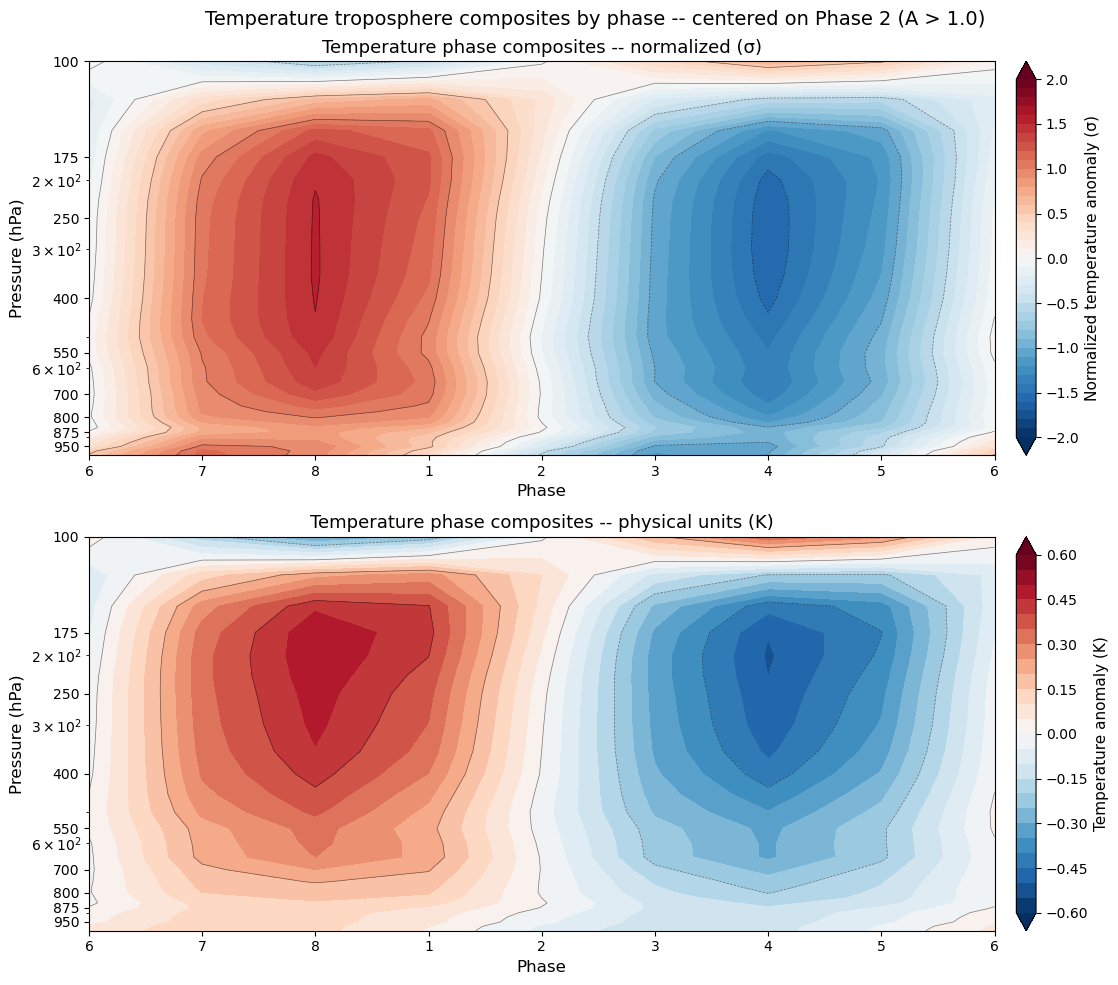

In [23]:
# Phase reordering centered on phase 2
phase_order  = [5, 6, 7, 0, 1, 2, 3, 4, 5]
phase_labels = [6, 7, 8, 1, 2, 3, 4, 5, 6]
phases_centered = np.arange(1, 10)

comp_temp_norm_centered     = comp_temp_norm[:, phase_order]     # shape (27, 9)
comp_temp_physical_centered = comp_temp_physical[:, phase_order] # shape (27, 9)

# Get temperature levels -- confirm same as tam_trop
t_levels = t_trop.level.values

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Normalized ---
ax = axes[0]
cf1 = ax.contourf(
    phases_centered, t_levels, comp_temp_norm_centered,
    levels=np.arange(-2, 2.1, 0.1),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, t_levels, comp_temp_norm_centered,
    levels=np.arange(-2, 2.1, 0.5),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('Temperature phase composites -- normalized (σ)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(t_levels[::3])
cbar1 = fig.colorbar(cf1, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label('Normalized temperature anomaly (σ)', fontsize=11)

# --- Physical units ---
ax = axes[1]
cf2 = ax.contourf(
    phases_centered, t_levels, comp_temp_physical_centered,
    levels=np.arange(-0.6, 0.61, 0.05),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, t_levels, comp_temp_physical_centered,
    levels=np.arange(-0.6, 0.61, 0.2),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('Temperature phase composites -- physical units (K)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(t_levels[::3])
cbar2 = fig.colorbar(cf2, ax=ax, orientation='vertical', pad=0.02)
cbar2.set_label('Temperature anomaly (K)', fontsize=11)

plt.suptitle('Temperature troposphere composites by phase -- centered on Phase 2 (A > 1.0)',
             fontsize=14)
plt.tight_layout()
#plt.savefig('Temp_phase_composites_centered.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
comp_wstar_physical, comp_wstar_norm = phase_composite(wstar_trop, phase, A, threshold=1.0)

In [25]:
print(f"w* physical range: {comp_wstar_physical.min():.6f} to {comp_wstar_physical.max():.6f}")
print(f"w* normalized range: {comp_wstar_norm.min():.3f} to {comp_wstar_norm.max():.3f}")

w* physical range: -0.001039 to 0.001300
w* normalized range: -0.293 to 0.331


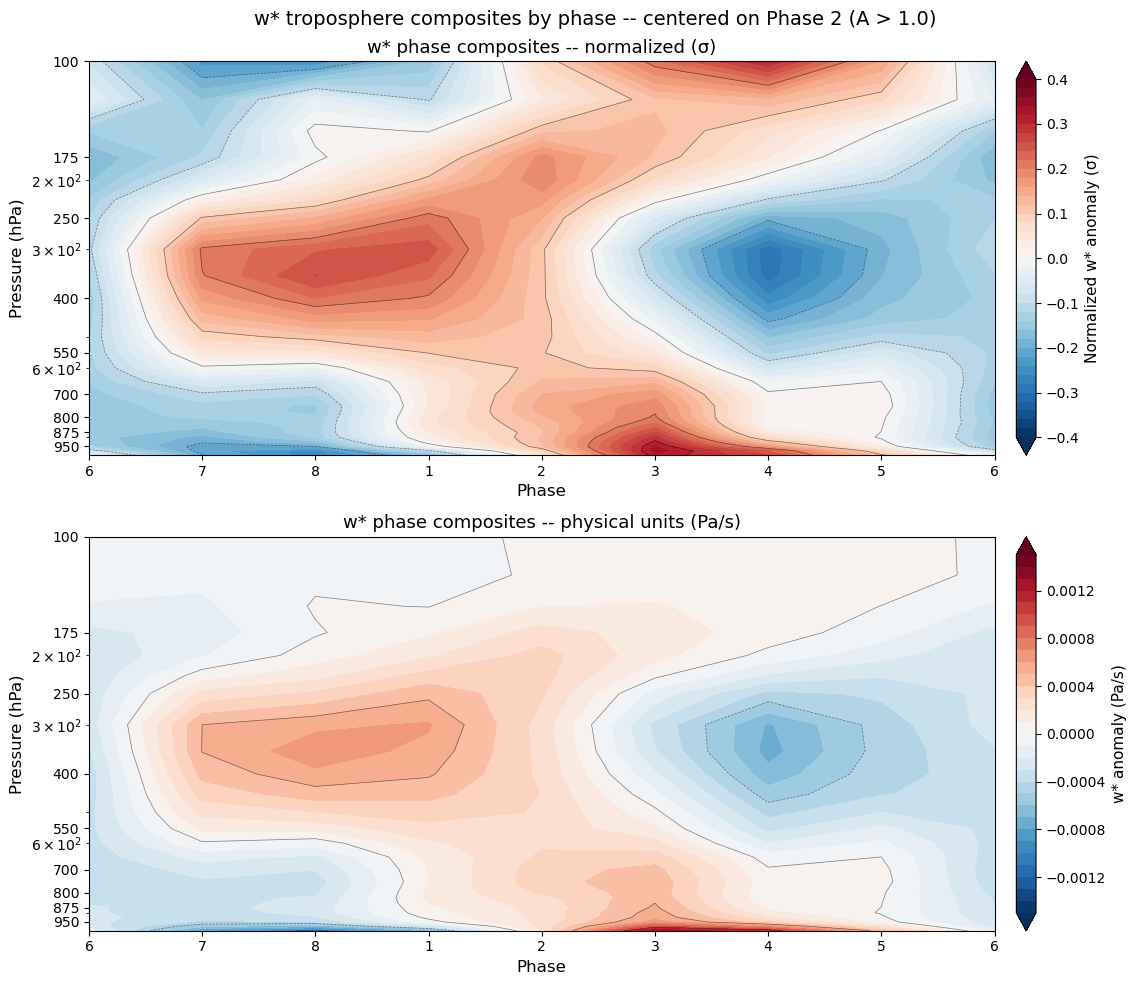

In [26]:
wstar_levels = wstar_trop.level.values

comp_wstar_norm_centered     = comp_wstar_norm[:, phase_order]     # shape (27, 9)
comp_wstar_physical_centered = comp_wstar_physical[:, phase_order] # shape (27, 9)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Normalized ---
ax = axes[0]
cf1 = ax.contourf(
    phases_centered, wstar_levels, comp_wstar_norm_centered,
    levels=np.arange(-0.4, 0.41, 0.02),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, wstar_levels, comp_wstar_norm_centered,
    levels=np.arange(-0.4, 0.41, 0.1),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('w* phase composites -- normalized (σ)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(wstar_levels[::3])
cbar1 = fig.colorbar(cf1, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label('Normalized w* anomaly (σ)', fontsize=11)

# --- Physical units ---
ax = axes[1]
cf2 = ax.contourf(
    phases_centered, wstar_levels, comp_wstar_physical_centered,
    levels=np.arange(-0.0015, 0.00151, 0.0001),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, wstar_levels, comp_wstar_physical_centered,
    levels=np.arange(-0.0015, 0.00151, 0.0005),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('w* phase composites -- physical units (Pa/s)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(wstar_levels[::3])
cbar2 = fig.colorbar(cf2, ax=ax, orientation='vertical', pad=0.02)
cbar2.set_label('w* anomaly (Pa/s)', fontsize=11)

plt.suptitle('w* troposphere composites by phase -- centered on Phase 2 (A > 1.0)',
             fontsize=14)
plt.tight_layout()
#plt.savefig('wstar_phase_composites_centered.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
comp_w_physical, comp_w_norm = phase_composite(w_trop, phase, A, threshold=1.0)

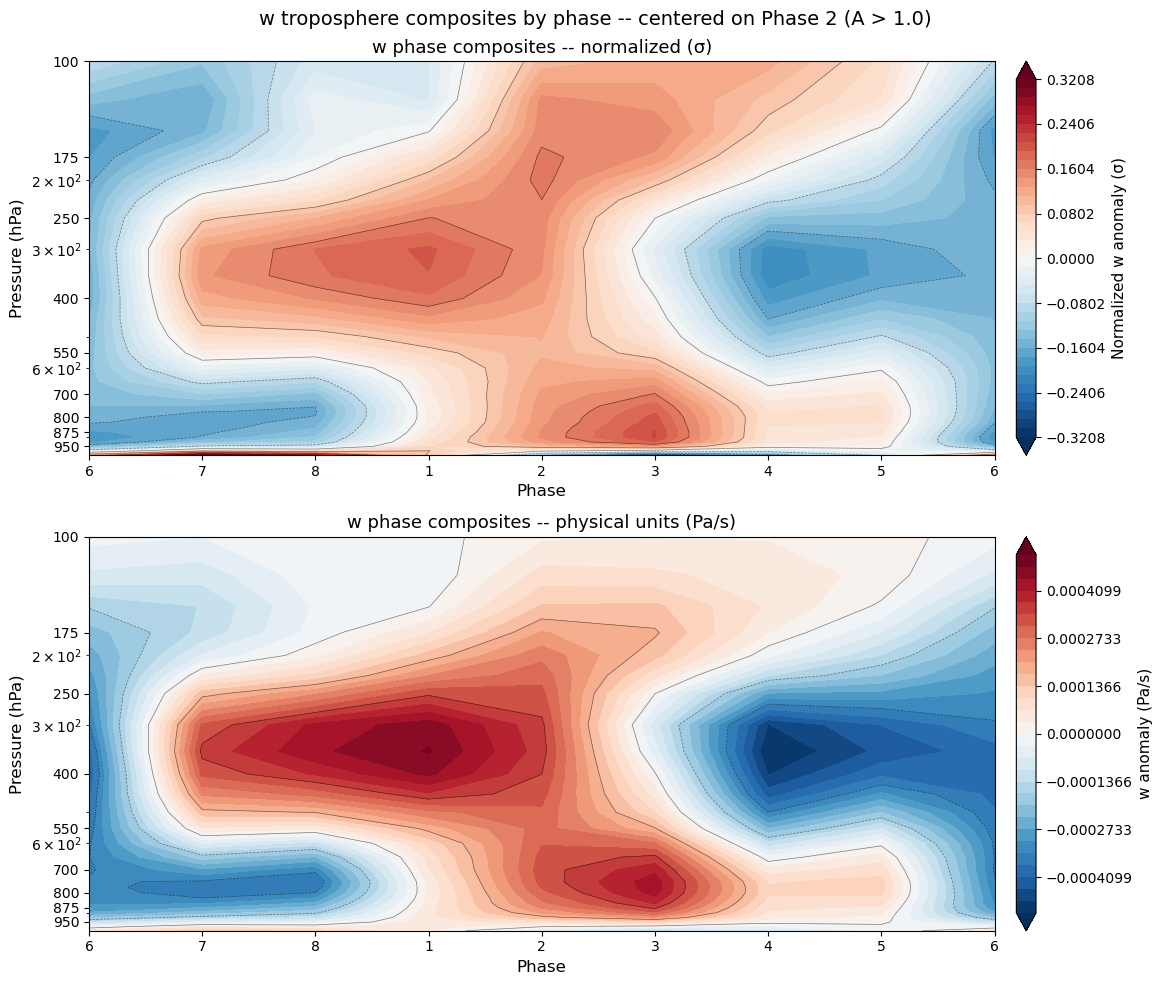

In [28]:
w_levels = w_trop.level.values

comp_w_norm_centered     = comp_w_norm[:, phase_order]     # shape (27, 9)
comp_w_physical_centered = comp_w_physical[:, phase_order] # shape (27, 9)

# Set contour levels from the actual composite range (symmetric around 0)
# -- w's magnitude isn't known ahead of time the way wstar's was, so derive bounds
norm_bound = np.nanmax(np.abs(comp_w_norm_centered))
phys_bound = np.nanmax(np.abs(comp_w_physical_centered))

norm_levels_fill    = np.linspace(-norm_bound, norm_bound, 41)
norm_levels_contour = np.linspace(-norm_bound, norm_bound, 9)

phys_levels_fill    = np.linspace(-phys_bound, phys_bound, 31)
phys_levels_contour = np.linspace(-phys_bound, phys_bound, 7)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Normalized ---
ax = axes[0]
cf1 = ax.contourf(
    phases_centered, w_levels, comp_w_norm_centered,
    levels=norm_levels_fill,
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, w_levels, comp_w_norm_centered,
    levels=norm_levels_contour,
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('w phase composites -- normalized (σ)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(w_levels[::3])
cbar1 = fig.colorbar(cf1, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label('Normalized w anomaly (σ)', fontsize=11)

# --- Physical units ---
ax = axes[1]
cf2 = ax.contourf(
    phases_centered, w_levels, comp_w_physical_centered,
    levels=phys_levels_fill,
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, w_levels, comp_w_physical_centered,
    levels=phys_levels_contour,
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('w phase composites -- physical units (Pa/s)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(w_levels[::3])
cbar2 = fig.colorbar(cf2, ax=ax, orientation='vertical', pad=0.02)
cbar2.set_label('w anomaly (Pa/s)', fontsize=11)

plt.suptitle('w troposphere composites by phase -- centered on Phase 2 (A > 1.0)',
             fontsize=14)
plt.tight_layout()
#plt.savefig('w_phase_composites_centered.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
comp_u_physical, comp_u_norm = phase_composite(u_trop, phase, A, threshold=1.0)

In [30]:
print(f"u physical range: {comp_u_physical.min():.3f} to {comp_u_physical.max():.3f} m/s")
print(f"u normalized range: {comp_u_norm.min():.3f} to {comp_u_norm.max():.3f}")

u physical range: -1.627 to 1.668 m/s
u normalized range: -0.697 to 0.732


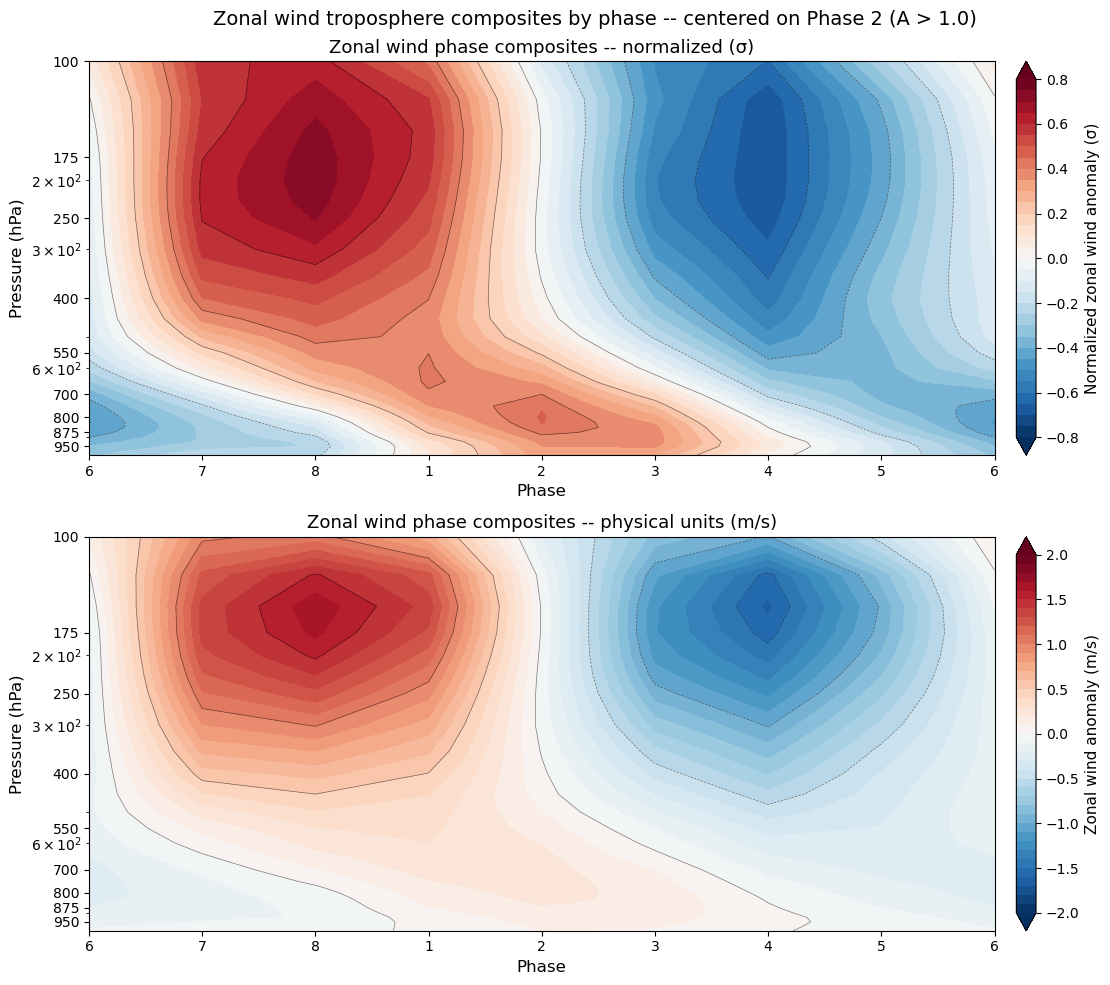

In [31]:
u_levels = u_trop.level.values

comp_u_norm_centered     = comp_u_norm[:, phase_order]     # shape (27, 9)
comp_u_physical_centered = comp_u_physical[:, phase_order] # shape (27, 9)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Normalized ---
ax = axes[0]
cf1 = ax.contourf(
    phases_centered, u_levels, comp_u_norm_centered,
    levels=np.arange(-0.8, 0.81, 0.05),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, u_levels, comp_u_norm_centered,
    levels=np.arange(-0.8, 0.81, 0.2),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('Zonal wind phase composites -- normalized (σ)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(u_levels[::3])
cbar1 = fig.colorbar(cf1, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label('Normalized zonal wind anomaly (σ)', fontsize=11)

# --- Physical units ---
ax = axes[1]
cf2 = ax.contourf(
    phases_centered, u_levels, comp_u_physical_centered,
    levels=np.arange(-2.0, 2.01, 0.1),
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, u_levels, comp_u_physical_centered,
    levels=np.arange(-2.0, 2.01, 0.5),
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title('Zonal wind phase composites -- physical units (m/s)', fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(u_levels[::3])
cbar2 = fig.colorbar(cf2, ax=ax, orientation='vertical', pad=0.02)
cbar2.set_label('Zonal wind anomaly (m/s)', fontsize=11)

plt.suptitle('Zonal wind troposphere composites by phase -- centered on Phase 2 (A > 1.0)',
             fontsize=14)
plt.tight_layout()
#plt.savefig('u_phase_composites_centered.png', dpi=300, bbox_inches='tight')
plt.show()

In [32]:
comp_upvpdiv_physical, comp_upvpdiv_norm = phase_composite(upvpconv_trop, phase, A, threshold=1.0)

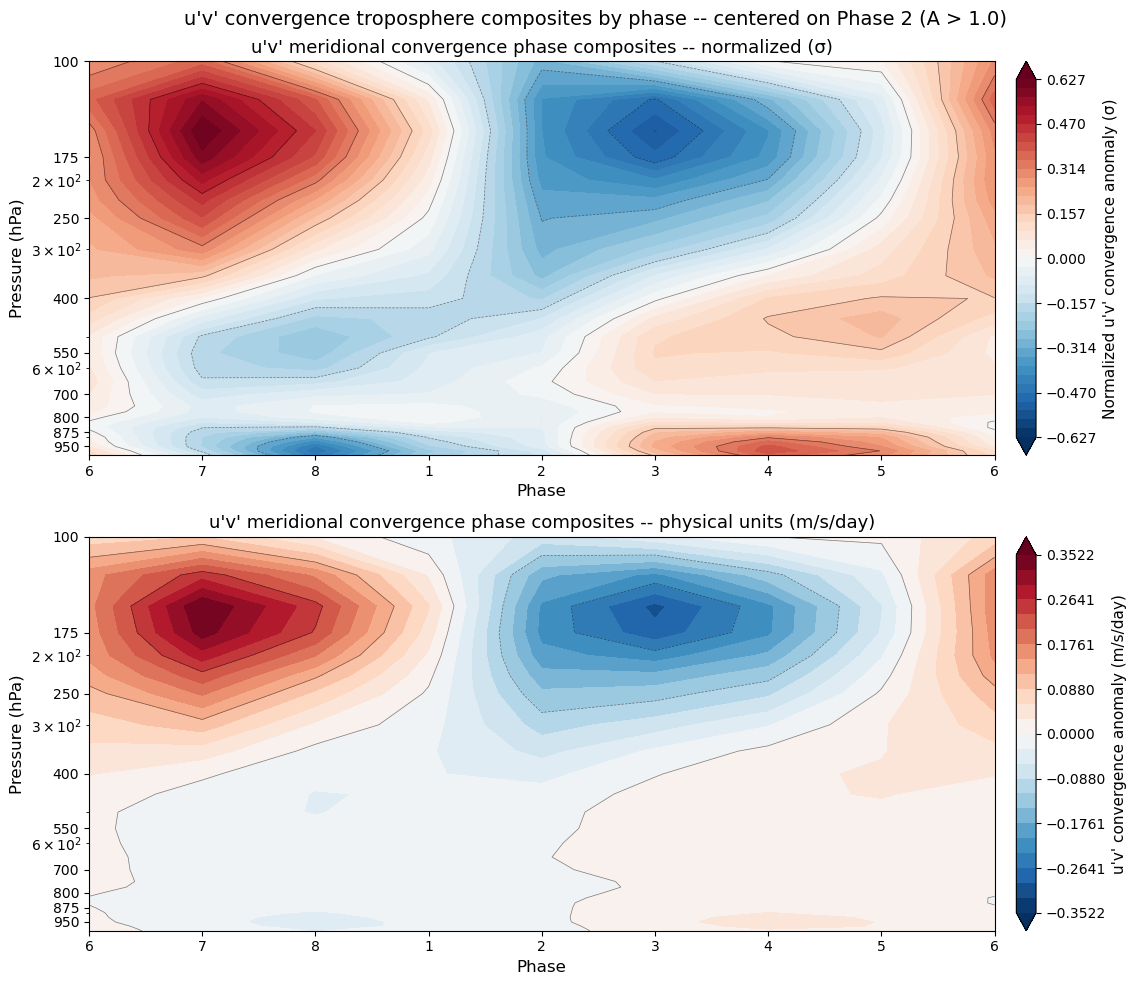

In [33]:
# Phase reordering centered on phase 2
phase_order  = [5, 6, 7, 0, 1, 2, 3, 4, 5]
phase_labels = [6, 7, 8, 1, 2, 3, 4, 5, 6]
phases_centered = np.arange(1, 10)

comp_upvpdiv_norm_centered     = comp_upvpdiv_norm[:, phase_order]     # shape (27, 9)
comp_upvpdiv_physical_centered = comp_upvpdiv_physical[:, phase_order] # shape (27, 9)

# Get levels -- confirm same as upvp_merid_div_trop
upvpdiv_levels = upvpconv_trop.level.values

# Set contour levels from the actual composite range (symmetric around 0)
norm_bound = np.nanmax(np.abs(comp_upvpdiv_norm_centered))
phys_bound = np.nanmax(np.abs(comp_upvpdiv_physical_centered))

norm_levels_fill    = np.linspace(-norm_bound, norm_bound, 41)
norm_levels_contour = np.linspace(-norm_bound, norm_bound, 9)

phys_levels_fill    = np.linspace(-phys_bound, phys_bound, 25)
phys_levels_contour = np.linspace(-phys_bound, phys_bound, 7)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Normalized ---
ax = axes[0]
cf1 = ax.contourf(
    phases_centered, upvpdiv_levels, comp_upvpdiv_norm_centered,
    levels=norm_levels_fill,
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, upvpdiv_levels, comp_upvpdiv_norm_centered,
    levels=norm_levels_contour,
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title("u'v' meridional convergence phase composites -- normalized (σ)", fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(upvpdiv_levels[::3])
cbar1 = fig.colorbar(cf1, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label("Normalized u'v' convergence anomaly (σ)", fontsize=11)

# --- Physical units ---
ax = axes[1]
cf2 = ax.contourf(
    phases_centered, upvpdiv_levels, comp_upvpdiv_physical_centered,
    levels=phys_levels_fill,
    cmap='RdBu_r',
    extend='both'
)
ax.contour(
    phases_centered, upvpdiv_levels, comp_upvpdiv_physical_centered,
    levels=phys_levels_contour,
    colors='k', linewidths=0.5, alpha=0.5
)
ax.set_yscale('log')
ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)', fontsize=12)
ax.set_title("u'v' meridional convergence phase composites -- physical units (m/s/day)", fontsize=13)
ax.set_xticks(phases_centered)
ax.set_xticklabels(phase_labels)
ax.set_xlabel('Phase', fontsize=12)
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_yticks(upvpdiv_levels[::3])
cbar2 = fig.colorbar(cf2, ax=ax, orientation='vertical', pad=0.02)
cbar2.set_label("u'v' convergence anomaly (m/s/day)", fontsize=11)

plt.suptitle("u'v' convergence troposphere composites by phase -- centered on Phase 2 (A > 1.0)",
             fontsize=14)
plt.tight_layout()
#plt.savefig('upvpdiv_phase_composites_centered.png', dpi=300, bbox_inches='tight')
plt.show()

## Height vs. Latitude Composites by Phase

In [34]:
def phase_composite_hl(var, phase, A, threshold=1.0):
    """
    TAM phase composites for a full-latitude variable (level, latitude, alltime).
    Returns composite_physical, composite_norm, both shape (level, latitude, 8).
    """
    n_phases = 8
    composite = np.zeros(var.values.shape[:-1] + (n_phases,))

    for p in range(1, n_phases + 1):
        mask = (phase == p) & (A > threshold)
        # mask = (phase == p) & (A > 1.414)
        # mask = (phase == p) & (A > 1.5)
        idx_phase = np.where(mask)[0]
        composite[..., p-1] = var.isel(alltime=idx_phase).mean(dim='alltime').values

    composite_physical = composite.copy()
    var_std = var.std(dim='alltime').values          # (level, latitude)
    composite_norm = composite / var_std[..., np.newaxis]

    return composite_physical, composite_norm

In [35]:
u_hl     = highpUshaved.sel(level=slice(100, 1000))
t_hl     = highpTshaved.sel(level=slice(100, 1000))
upvp_hl  = highpupvpshaved.sel(level=slice(100, 1000))
wstar_hl = highpwstarshaved.sel(level=slice(100, 1000))
w_hl     = highpWshaved.sel(level=slice(100, 1000))

lat_arr    = u_hl.latitude.values
levels_arr = u_hl.level.values

In [36]:
comp_u_hl_phys,     comp_u_hl_norm     = phase_composite_hl(u_hl,     phase, A, threshold=1.0)
comp_t_hl_phys,     comp_t_hl_norm     = phase_composite_hl(t_hl,     phase, A, threshold=1.0)
comp_upvp_hl_phys,  comp_upvp_hl_norm  = phase_composite_hl(upvp_hl,  phase, A, threshold=1.0)
comp_wstar_hl_phys, comp_wstar_hl_norm = phase_composite_hl(wstar_hl, phase, A, threshold=1.0)
comp_w_hl_phys,     comp_w_hl_norm     = phase_composite_hl(w_hl,     phase, A, threshold=1.0)

/glade/derecho/scratch/leonardgu/tmp/ipykernel_67715/1059325063.py:18: RuntimeWarning: invalid value encountered in divide
  composite_norm = composite / var_std[..., np.newaxis]


In [37]:
def plot_height_lat_composite(comp_physical, comp_norm, levels_arr, lat_arr,
                               varname, units, use_norm=True):
    data = comp_norm if use_norm else comp_physical
    bound = np.nanmax(np.abs(data))
    fill_levels    = np.linspace(-bound, bound, 25)
    contour_levels = np.linspace(-bound, bound, 7)

    phase_order_hl  = [5, 6, 7, 0, 1, 2, 3, 4]   # centered-on-2 reading order, no wraparound repeat
    phase_labels_hl = [6, 7, 8, 1, 2, 3, 4, 5]

    fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
    for ax, p_idx, p_lab in zip(axes.flat, phase_order_hl, phase_labels_hl):
        cf = ax.contourf(lat_arr, levels_arr, data[:, :, p_idx],
                          levels=fill_levels, cmap='RdBu_r', extend='both')
        ax.contour(lat_arr, levels_arr, data[:, :, p_idx],
                   levels=contour_levels, colors='k', linewidths=0.4, alpha=0.5)
        ax.set_yscale('log')
        ax.set_ylim(1000, 100)
        ax.set_xlim(-90, 90)
        ax.set_title(f'Phase {p_lab}', fontsize=11)
        ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

    for ax in axes[:, 0]:
        ax.set_ylabel('Pressure (hPa)')
    for ax in axes[-1, :]:
        ax.set_xlabel('Latitude')

    label = f'Normalized {varname} anomaly (σ)' if use_norm else f'{varname} anomaly ({units})'
    fig.colorbar(cf, ax=axes, orientation='vertical', pad=0.02, label=label)
    fig.suptitle(f'{varname} height-latitude composites by phase (A > 1.0)', fontsize=15)
    #plt.savefig(f'{varname}_heightlat_phase_composites.png', dpi=300, bbox_inches='tight')
    plt.show()

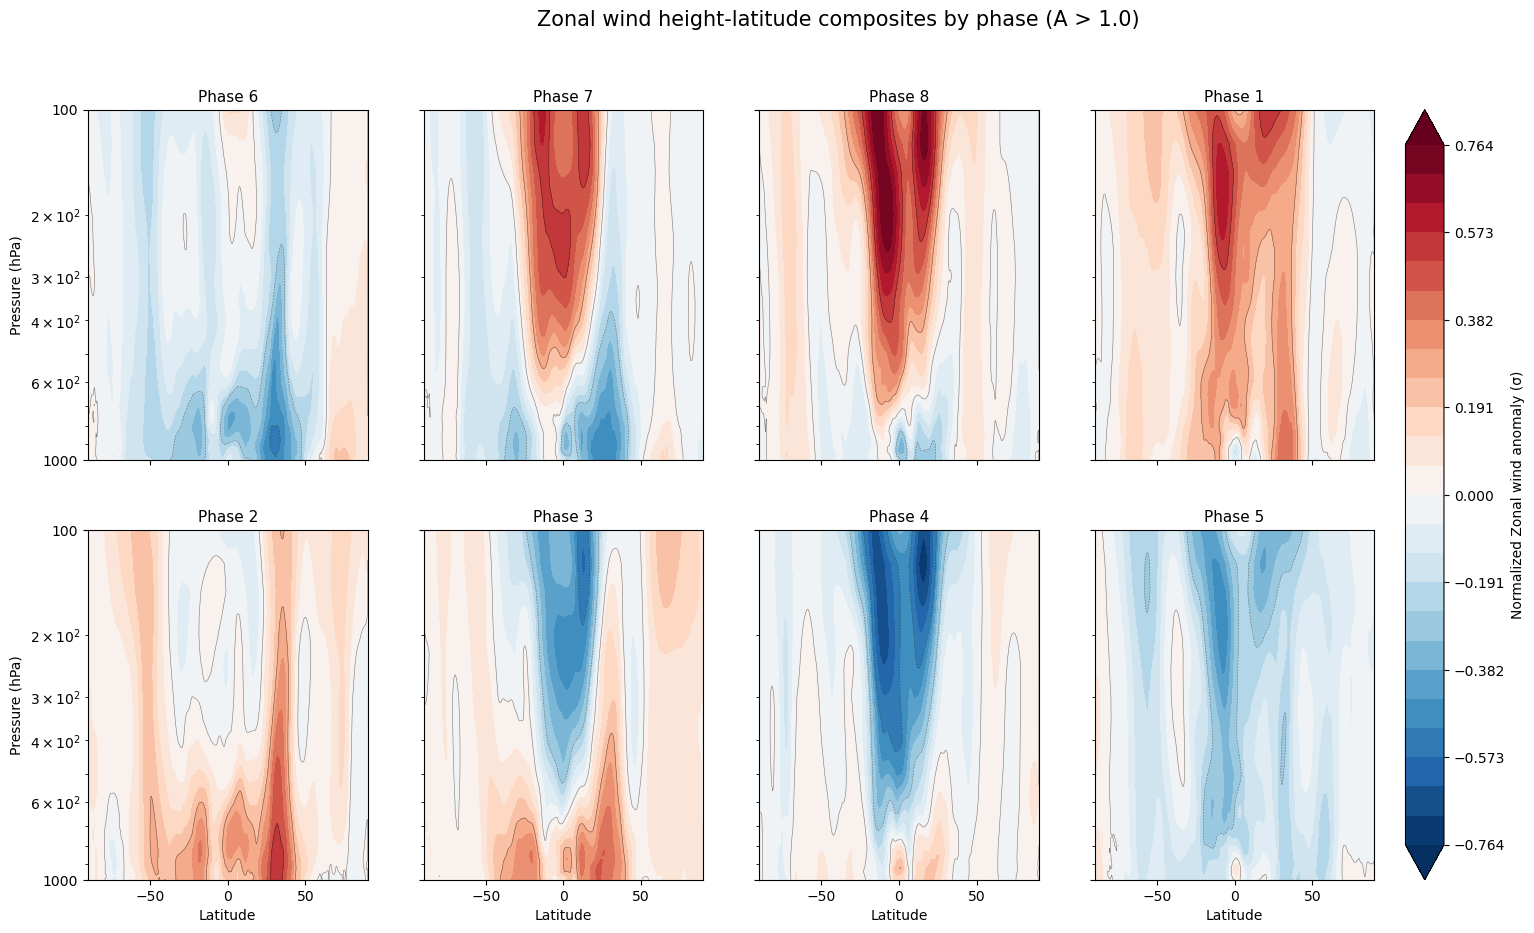

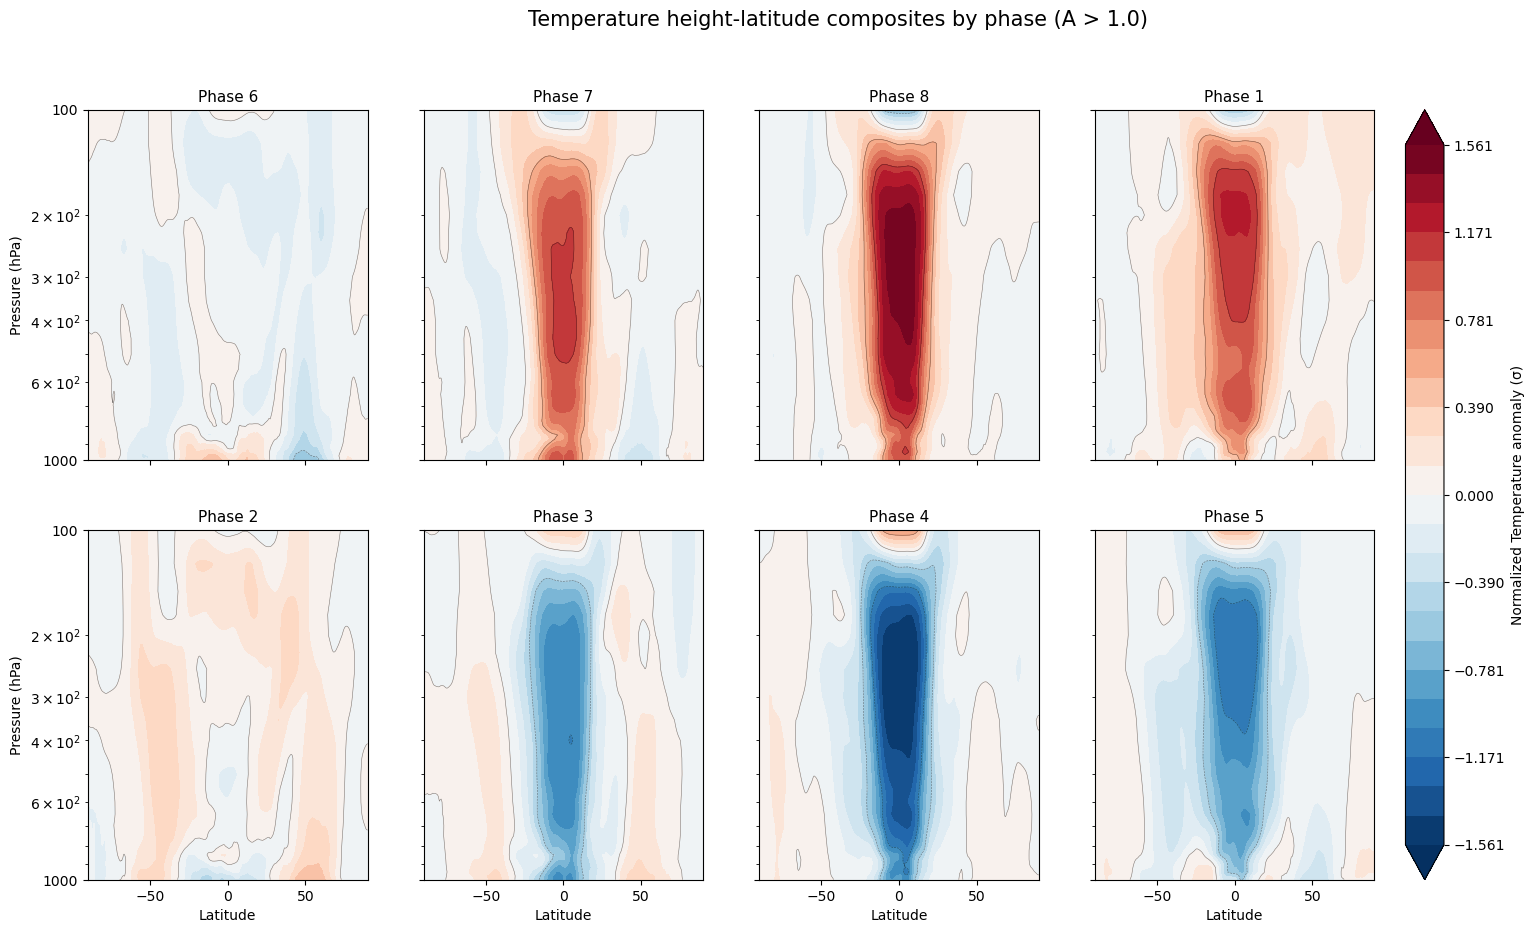

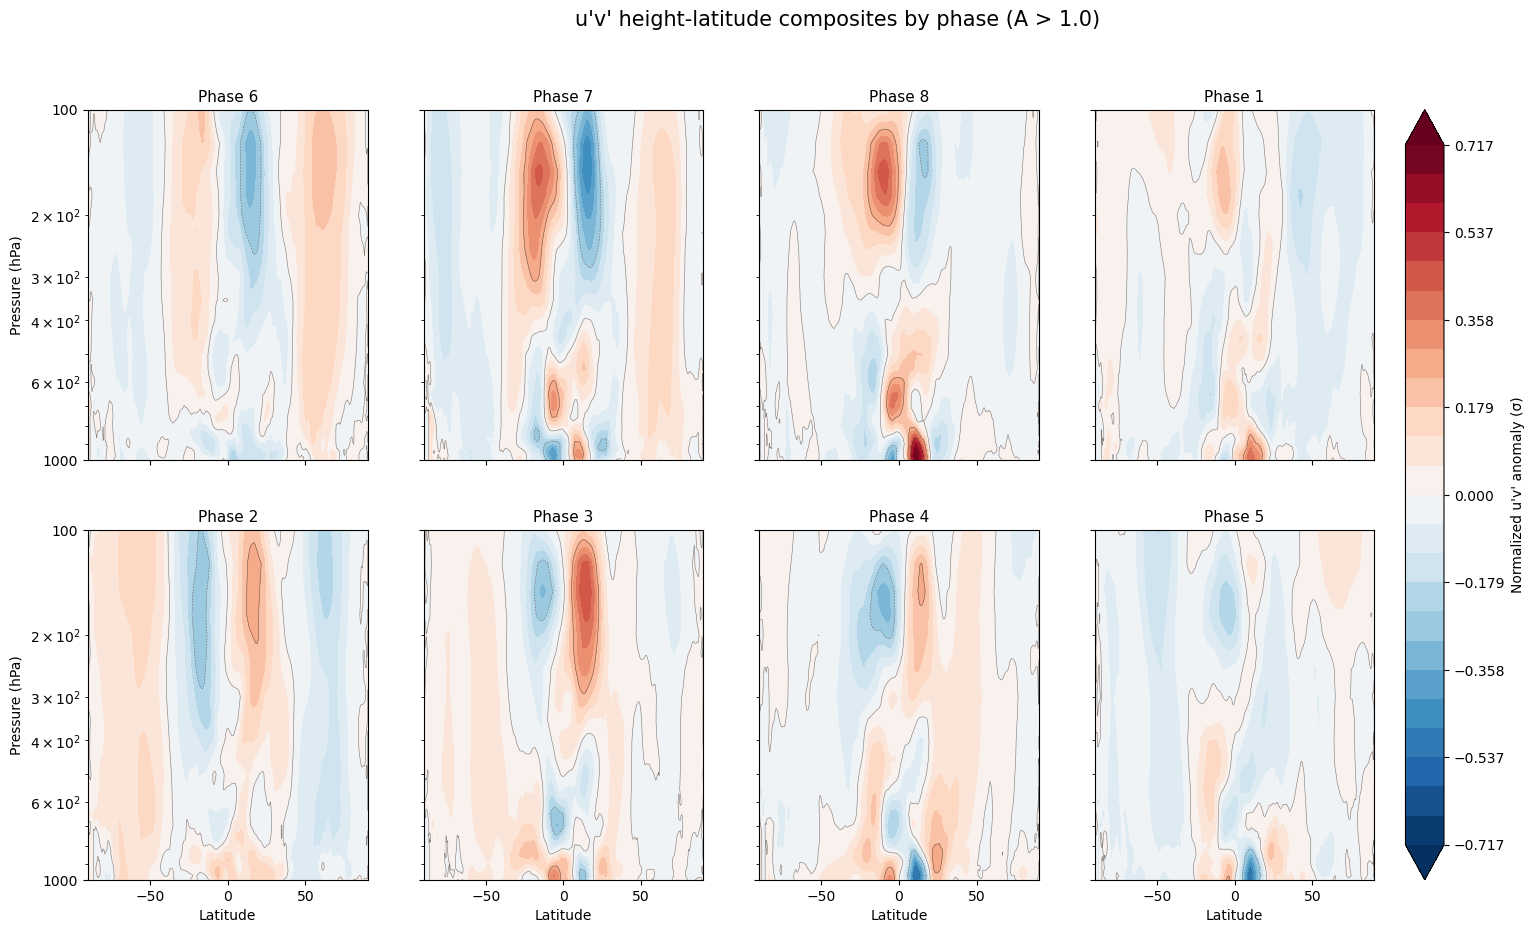

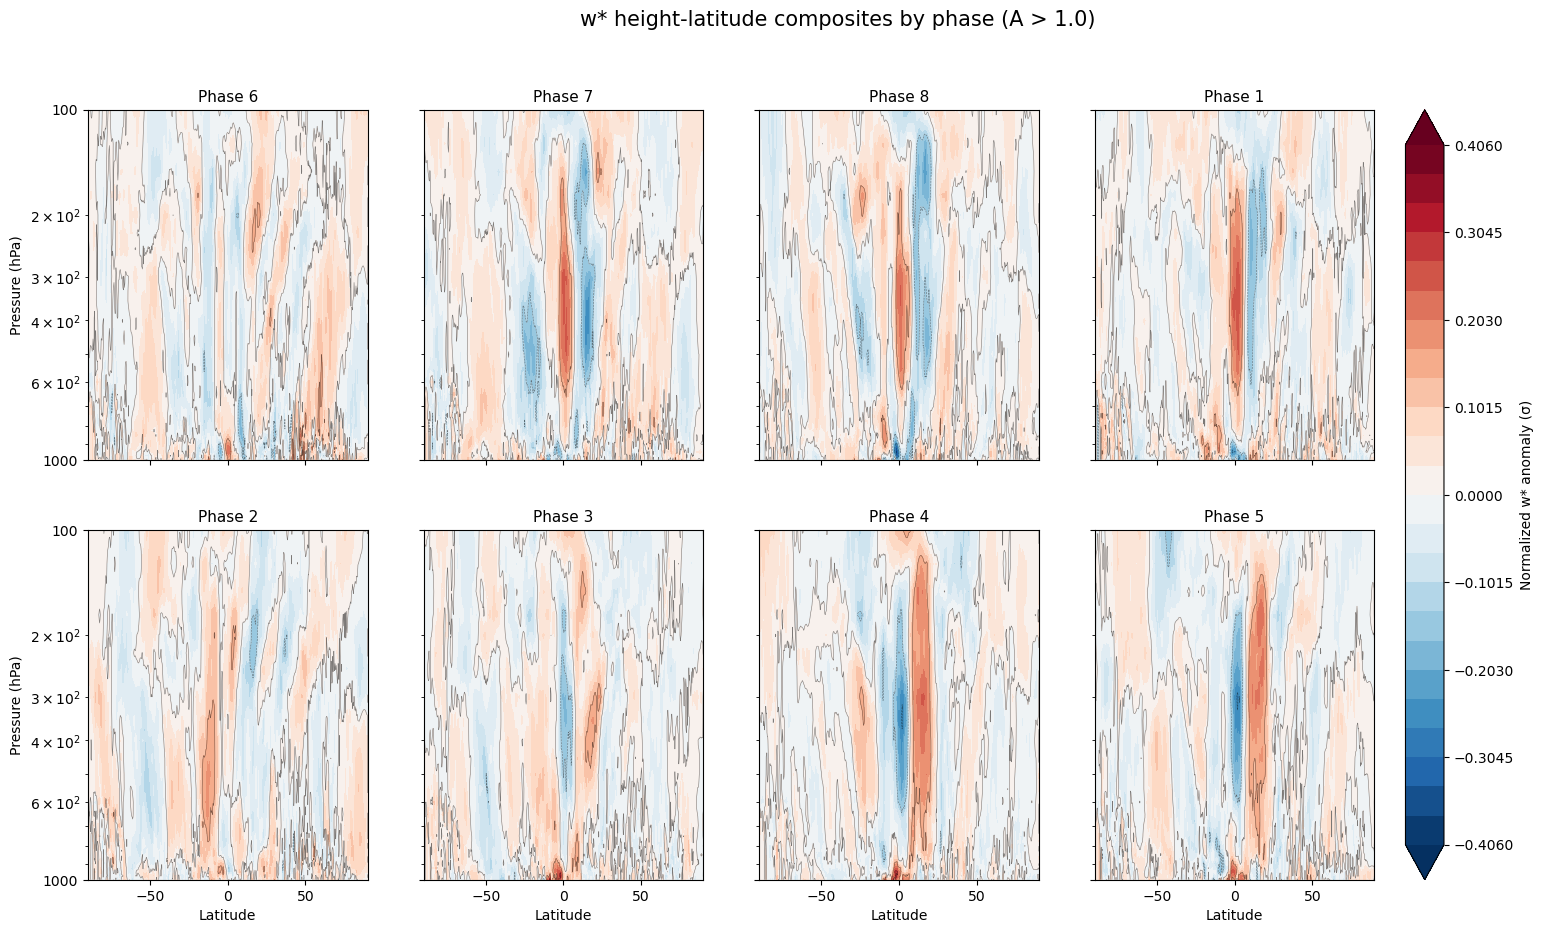

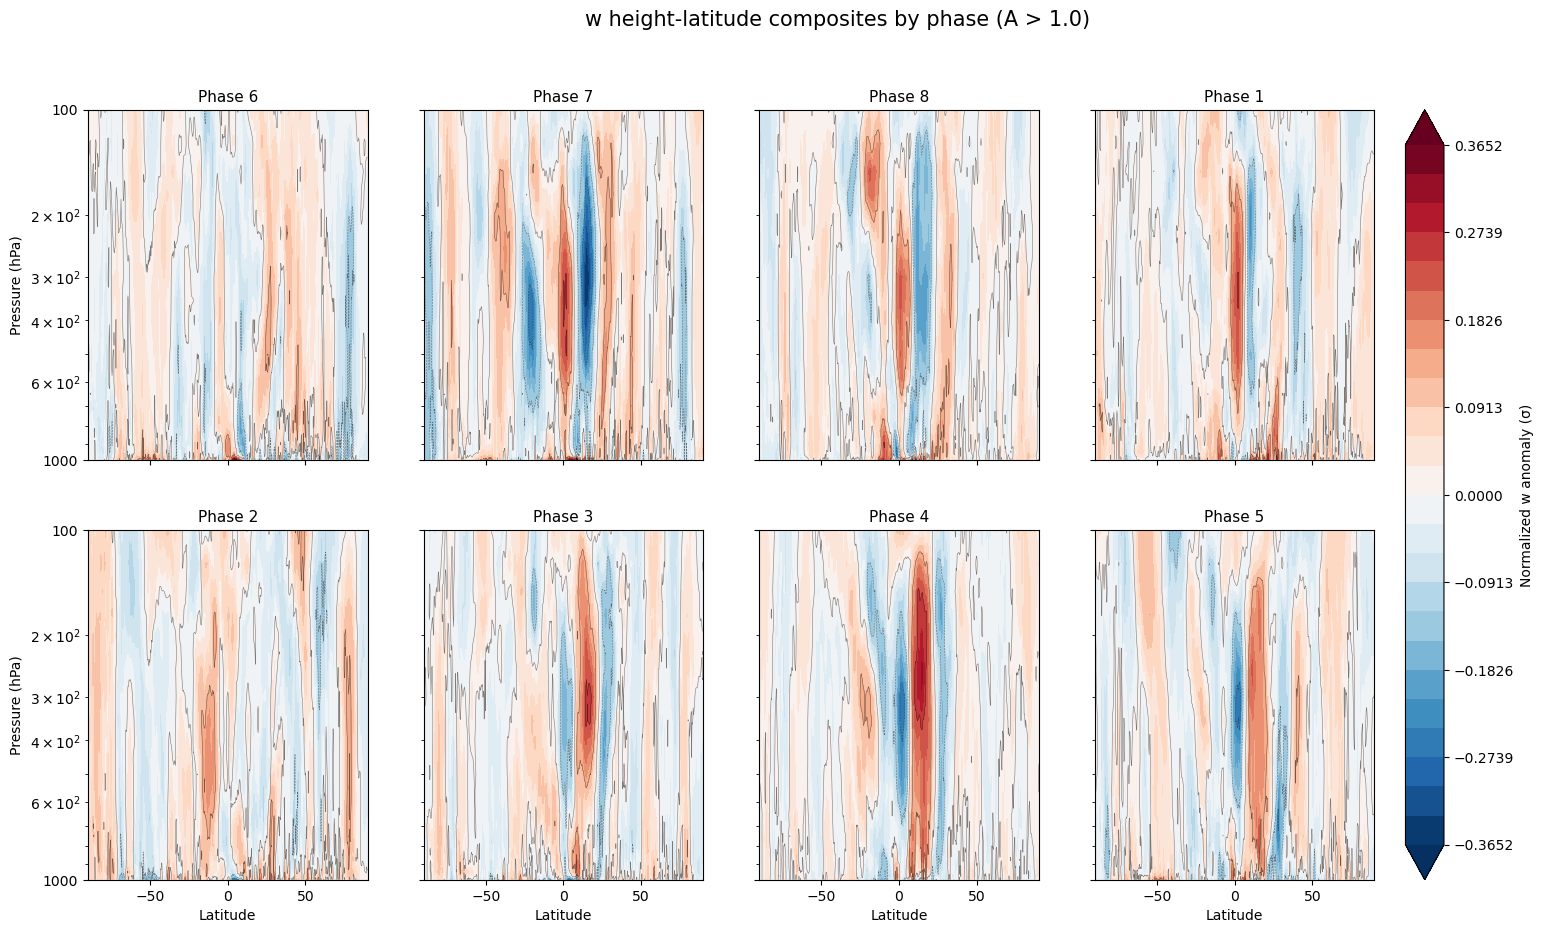

In [38]:
plot_height_lat_composite(comp_u_hl_phys,     comp_u_hl_norm,     levels_arr, lat_arr, 'Zonal wind', 'm/s')
plot_height_lat_composite(comp_t_hl_phys,     comp_t_hl_norm,     levels_arr, lat_arr, 'Temperature', 'K')
plot_height_lat_composite(comp_upvp_hl_phys,  comp_upvp_hl_norm,  levels_arr, lat_arr, "u'v'", "m2/s2")
plot_height_lat_composite(comp_wstar_hl_phys, comp_wstar_hl_norm, levels_arr, lat_arr, 'w*', 'Pa/s')
plot_height_lat_composite(comp_w_hl_phys,     comp_w_hl_norm,     levels_arr, lat_arr, 'w', 'Pa/s')

### Saving index

In [39]:
np.savez('tam_eof_phase_index.npz',
    eigenvalues=evaltrop,
    eigenvectors=evectrop,
    A_half=A_half_trop,
    var_fractions=var_fractions_trop,
    PCs=PCstrop,         
    phi=phi,
    A=A,
    phase=phase,
    year=tam_trop.alltime.get_index('alltime').get_level_values('year'),
    time=tam_trop.alltime.get_index('alltime').get_level_values('time'),
)

### Transition Matrix Evaluation

In [40]:
def empirical_transition_matrix(phase, lag):
    """
    Empirical P(phase_{t+lag} = j | phase_t = i), estimated directly
    from observed frequencies -- no Markov assumption involved.
    """
    M = np.zeros((8, 8))
    p_now = phase[:-lag]
    p_later = phase[lag:]
    for i in range(1, 9):
        mask = (p_now == i)
        if mask.sum() > 0:
            for j in range(1, 9):
                M[i-1, j-1] = np.sum(p_later[mask] == j) / mask.sum()
    return M

# sanity check -- every row should sum to ~1
#lags = [1, 5, 10, 20]
#M = {lag: empirical_transition_matrix(phase, lag) for lag in lags}
#for lag in lags:
    #print(f"lag={lag}: row sums = {M[lag].sum(axis=1)}")

In [41]:
def plot_transition_matrix(Mlag, lag, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(Mlag, cmap='viridis', vmin=0, vmax=Mlag.max())
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    ax.set_xticklabels(range(1, 9))
    ax.set_yticklabels(range(1, 9))
    ax.set_xlabel(f'Phase at t+{lag}')
    ax.set_ylabel('Phase at t')
    ax.set_title(f'Empirical transition matrix (lag={lag} day)')

    # annotate each cell with its probability
    for i in range(8):
        for j in range(8):
            val = Mlag[i, j]
            color = 'white' if val < Mlag.max()/2 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=9)

    plt.colorbar(im, ax=ax, label='Probability')
    plt.tight_layout()
    plt.show()


In [42]:
lags = list(range(1, 41))
M = {lag: empirical_transition_matrix(phase, lag) for lag in lags}

In [43]:
for lag in lags:
    print(f"lag={lag}: row sums = {M[lag].sum(axis=1)}")

lag=1: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=2: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=3: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=4: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=5: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=6: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=7: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=8: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=9: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=10: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=11: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=12: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=13: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=14: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=15: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=16: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=17: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=18: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=19: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=20: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=21: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=22: row sums = [1. 1. 1. 1. 1. 1. 1. 1.]
lag=23: row sums = 

In [44]:
from ipywidgets import interact, IntSlider

def plot_transition_matrix_interactive(lag):
    Mlag = M[lag]
    vmax = Mlag.max()   # scaled per-frame now

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(Mlag, cmap='viridis', vmin=0, vmax=vmax)
    ax.set_xticks(range(8)); ax.set_yticks(range(8))
    ax.set_xticklabels(range(1, 9)); ax.set_yticklabels(range(1, 9))
    ax.set_xlabel('Phase at t+lag')
    ax.set_ylabel('Phase at t')
    ax.set_title(f'Empirical transition matrix (lag={lag} day)')

    for i in range(8):
        for j in range(8):
            val = Mlag[i, j]
            color = 'white' if val < vmax/2 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=9)

    plt.colorbar(im, ax=ax, label='Probability')
    plt.tight_layout()
    plt.show()

interact(plot_transition_matrix_interactive, lag=IntSlider(min=1, max=40, step=1, value=1));

interactive(children=(IntSlider(value=1, description='lag', max=40, min=1), Output()), _dom_classes=('widget-i…

### Phase-space binning and mean velocity

In [45]:
"""
Compute instantaneous angular and radial velocity in EOF1-EOF2 phase space.

Uses a centered finite difference (x[t+1]-x[t-1])/2 rather than a forward
difference, since it is second-order accurate and represents the velocity
AT time t (the midpoint of the t-1, t+1 interval) rather than at an
unobserved half-step.

Angular velocity is computed via the analytic polar identity
    theta_dot = (x*y_dot - y*x_dot) / r^2
rather than differencing phi directly, because phi wraps at +/-180 deg and
a naive difference would spike near the wrap boundary. This formula avoids
that entirely by working in Cartesian (PC1, PC2) space.

radial velocity (vr) is the outward component of velocity; it should be
~0 on average if the motion is rotational rather than spiraling in/out.

Outputs (all length nt-2, one entry per interior day):
    omega_deg   -- angular velocity, deg/day (+ = CCW under phi=atan2(PC2,PC1))
    vr          -- radial velocity, PC-units/day
    r_mid       -- amplitude A at the midpoint day
    theta_mid_deg -- phase angle at the midpoint day
"""

x, y = PCstrop[0], PCstrop[1]   # PC1, PC2, unit-variance normalized
dt = 1.0  # daily spacing

dx_dt = (x[2:] - x[:-2]) / (2*dt)
dy_dt = (y[2:] - y[:-2]) / (2*dt)
x_mid, y_mid = x[1:-1], y[1:-1]
r_mid = np.sqrt(x_mid**2 + y_mid**2)

omega = (x_mid*dy_dt - y_mid*dx_dt) / r_mid**2      # rad/day, angular velocity
omega_deg = np.degrees(omega)                        # deg/day
vr = (x_mid*dx_dt + y_mid*dy_dt) / r_mid             # radial velocity, expect ~0

theta_mid_deg = np.degrees(np.arctan2(y_mid, x_mid))

In [46]:
"""
Bin (r, theta) phase space into a grid and compute mean/std/count of
angular and radial velocity within each cell.

r_bin_edges starts at A=1.0 (the existing amplitude threshold) rather than
0, since omega's r^2 denominator makes the calculation unreliable and the
phase angle itself poorly defined near the origin.
    # alt bin starts to try: 0.5, 1.414 (sqrt(2)), 1.5 -- matches other
    # amplitude threshold conventions used elsewhere in this analysis

theta_bin_edges splits the full circle into 22.5 deg sectors (16 bins);
try 45 deg (8 bins, matching the phase-composite convention) if sectors
are too sparse.

For each (r-bin, theta-bin) cell, mask selects days whose amplitude AND
angle both fall in that cell (binning both dimensions jointly, not
independently), then averages omega_deg and vr over just those days.
counts records sample size per cell -- needed to judge reliability, since
a mean from a handful of days is not trustworthy.

se_omega/se_vr = std/sqrt(counts) are the standard errors of these means,
used next to test whether a cell's average velocity is a real signal
(|mean/se| >> 2) or just noise from a small sample.
"""

r_bin_edges = np.arange(1.0, 5.25, 0.5)          # starts at A=1.0 threshold; origin ill-defined below this
theta_bin_edges = np.arange(-180, 202.5, 22.5)   # 16 angular sectors; try 8 (45 deg) if bins are too sparse

r_idx = np.digitize(r_mid, r_bin_edges)
theta_idx = np.digitize(theta_mid_deg, theta_bin_edges)
n_r, n_th = len(r_bin_edges)-1, len(theta_bin_edges)-1

mean_omega = np.full((n_r, n_th), np.nan)
std_omega  = np.full((n_r, n_th), np.nan)
mean_vr    = np.full((n_r, n_th), np.nan)
std_vr     = np.full((n_r, n_th), np.nan)
counts     = np.zeros((n_r, n_th), dtype=int)

for i in range(n_r):
    for j in range(n_th):
        mask = (r_idx == i+1) & (theta_idx == j+1)
        n = mask.sum()
        counts[i, j] = n
        if n > 0:
            mean_omega[i, j] = omega_deg[mask].mean()
            std_omega[i, j]  = omega_deg[mask].std()
            mean_vr[i, j]    = vr[mask].mean()
            std_vr[i, j]     = vr[mask].std()

se_omega = std_omega / np.sqrt(counts)
se_vr    = std_vr / np.sqrt(counts)

In [47]:
print("Bin counts (want no near-empty bins):")
print(counts)

print("\nmean_omega (deg/day) -- want consistent sign across bins:")
print(np.round(mean_omega, 3))

print("\nmean_omega / se_omega (significance, |value| >> 2 is a confident detection):")
print(np.round(mean_omega / se_omega, 2))

print("\nmean_vr -- want near-zero relative to se_vr:")
print(np.round(mean_vr, 4))
print(np.round(mean_vr / se_vr, 2))

Bin counts (want no near-empty bins):
[[273 254 263 283 256 279 298 311 257 299 311 266 277 299 271 267]
 [213 185 152 193 215 182 215 212 161 188 206 171 169 197 189 209]
 [ 95 111  79  91  97  90  72  87  87  69 101 102  98 121 126  78]
 [ 32  51  34  38  37  28  36  29  24  14  35  23  25  24  21  12]
 [  4   9  12  17   8   3  12  10  10   4   8  11   5   7   9  12]
 [  0   4   5   5   3   0   0   3   8   5   4   0   3   0   4   6]
 [  0   0   1   0   0   0   0   3   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   1   2   0   0   0   0   0   0]]

mean_omega (deg/day) -- want consistent sign across bins:
[[ 3.886  3.307  3.366  3.35   1.964  3.982  3.137  2.979  2.734  3.716
   2.827  4.413  3.236  2.717  3.807  2.706]
 [ 2.219  1.791  3.337  1.885  2.756  2.174  1.788  1.869  4.192  3.45
   3.175  2.66   2.891  2.471  2.2    3.157]
 [ 1.491  2.026  3.208  3.847  2.92   2.629  3.017  2.586  3.213  2.793
   3.352  4.282  2.416  2.022  0.86   1.248]
 [ 2.481  2.9   

/glade/derecho/scratch/leonardgu/tmp/ipykernel_67715/3904923819.py:8: RuntimeWarning: divide by zero encountered in divide
  print(np.round(mean_omega / se_omega, 2))
/glade/derecho/scratch/leonardgu/tmp/ipykernel_67715/3904923819.py:12: RuntimeWarning: divide by zero encountered in divide
  print(np.round(mean_vr / se_vr, 2))


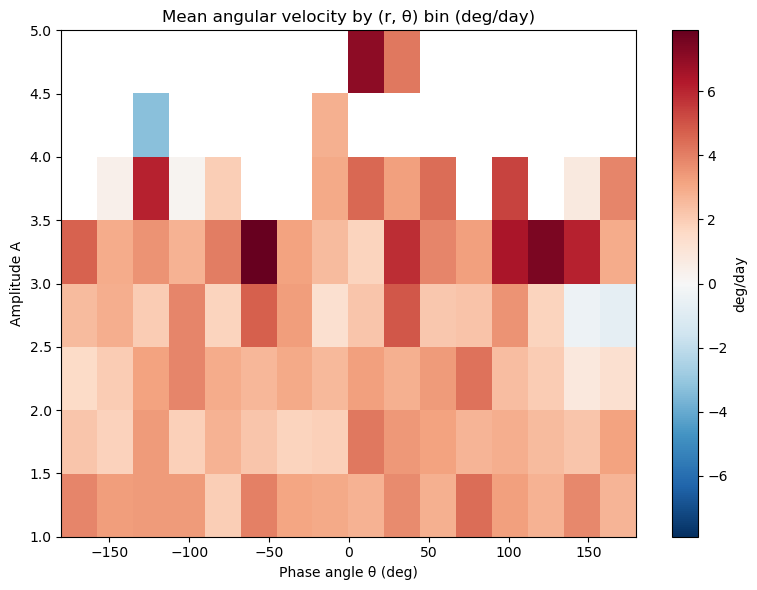

In [48]:
fig, ax = plt.subplots(figsize=(8, 6))
vbound = np.nanmax(np.abs(mean_omega))
im = ax.imshow(mean_omega, cmap='RdBu_r', vmin=-vbound, vmax=vbound,
               aspect='auto', origin='lower',
               extent=[theta_bin_edges[0], theta_bin_edges[-1], r_bin_edges[0], r_bin_edges[-1]])
ax.set_xlabel('Phase angle θ (deg)')
ax.set_ylabel('Amplitude A')
ax.set_title('Mean angular velocity by (r, θ) bin (deg/day)')
plt.colorbar(im, ax=ax, label='deg/day')
plt.tight_layout()
plt.show()

### Plotting trajectories (better version!)

In [49]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

def plot_trajectory_gradient(pc1, pc2, time_vals=None, cmap='twilight',
                              ax=None, title='', cbar_label='Day'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    if time_vals is None:
        time_vals = np.arange(len(pc1))

    points = np.array([pc1, pc2]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(time_vals.min(), time_vals.max())
    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=1.8)
    lc.set_array(time_vals[:-1])
    ax.add_collection(lc)

    # sector reference lines / phase labels stay -- these aren't redundant,
    # only the discrete per-segment coloring was
    for angle in np.arange(-22.5, 360, 45):
        rad = np.deg2rad(angle)
        ax.plot([0, 4*np.cos(rad)], [0, 4*np.sin(rad)],
                color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
    for p, angle in enumerate(np.arange(0, 360, 45), start=1):
        rad = np.deg2rad(angle)
        ax.text(3.5*np.cos(rad), 3.5*np.sin(rad), str(p),
                ha='center', va='center', fontsize=10, fontweight='bold', alpha=0.6)

    ax.scatter(pc1[0], pc2[0], s=150, color='k', marker='o', zorder=5, label='Start')
    ax.scatter(pc1[-1], pc2[-1], s=150, color='k', marker='*', zorder=5, label='End')

    ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9, loc='upper right')

    cbar = plt.colorbar(lc, ax=ax, pad=0.02)
    cbar.set_label(cbar_label, fontsize=11)
    return ax

In [50]:
year_coord = tam_trop.alltime.get_index('alltime').get_level_values('year')
time_coord = tam_trop.alltime.get_index('alltime').get_level_values('time')

mask_event = (year_coord == 2006) & (time_coord == 186)  # DOY 186 = July 5
idx_event = np.where(mask_event)[0]

print(f"Index of 2006-07-05: {idx_event}")
print(f"Amplitude on that day: {A[idx_event[0]]:.3f}")
print(f"Phase on that day: {phase[idx_event[0]]}")

Index of 2006-07-05: [9857]
Amplitude on that day: 4.034
Phase on that day: 1


<Axes: title={'center': 'TAM phase space -- 2006-07-05 event (days -40 to +40)'}, xlabel='PC1', ylabel='PC2'>

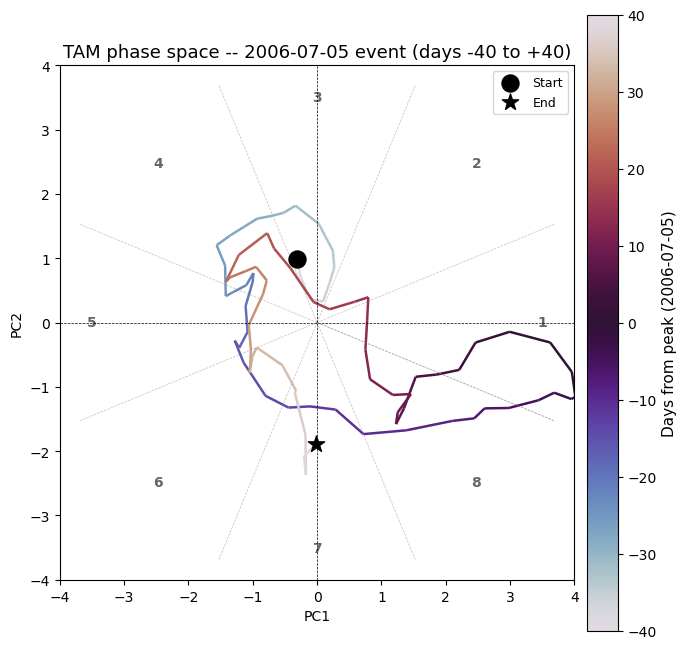

In [51]:
window = 40
event_idx = idx_event[0]
win_start, win_end = event_idx - window, event_idx + window + 1  # +1 for inclusive end, matches your earlier convention

plot_trajectory_gradient(
    PCstrop[0][win_start:win_end], PCstrop[1][win_start:win_end],
    time_vals=np.arange(-window, window + 1),
    cmap='twilight', cbar_label='Days from peak (2006-07-05)',
    title='TAM phase space -- 2006-07-05 event (days -40 to +40)'
)